# Week 13: LLM and RAG in Healthcare — Refactored Lab

**Course:** Digital Health and AI in Medical Applications (BME 7451)  
**Instructor:** Prof. Che-Wei Lin, NCKU BME

## Lab Story

A 3 AM emergency resident faces a rare, high-risk clinical case. A direct LLM can answer quickly, but it may hallucinate. In this lab, you will build a small Retrieval-Augmented Generation (RAG) system that retrieves guideline evidence before generating an answer.

## What You Will Build

1. A direct LLM clinical query with fallback mode.
2. A prompt engineering comparison: zero-shot, few-shot, and structured clinical reasoning style prompting.
3. A hallucination detection workflow for fabricated clinical citations.
4. A clinical RAG pipeline: chunking, embeddings, ChromaDB, retrieval, and grounded generation.
5. A retrieval evaluation workflow to inspect whether the system found useful evidence.

> **Clinical safety note:** This notebook is for education. The guideline passages are synthetic summaries unless replaced with verified clinical sources. Do not use generated output for patient care.


## 0. Setup Checklist

Run this section first. The notebook supports two modes:

- **Gemini mode:** Uses `GOOGLE_API_KEY` from Colab Secrets or environment variables.
- **Fallback mode:** Uses deterministic synthetic responses so the lab still runs without an API key.

Expected runtime: the first embedding model download may take several minutes.


In [1]:
# ============================================================
# Section 0: Environment Setup
# ============================================================

# If you are running in Colab, keep this install cell.
# If you are running locally, prefer a requirements.txt or virtual environment.
!pip install langchain langchain-community langchain-core langchain-text-splitters langchain-google-genai chromadb sentence-transformers google-generativeai --quiet

import os
import re
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")

print("Core libraries loaded.")

# --- Gemini API Setup ---
USE_GEMINI = False
llm = None

try:
    import google.generativeai as genai

    try:
        from google.colab import userdata
        API_KEY = userdata.get("GOOGLE_API_KEY")
    except Exception:
        API_KEY = os.environ.get("GOOGLE_API_KEY", "")

    if API_KEY:
        genai.configure(api_key=API_KEY)
        llm = genai.GenerativeModel("gemini-1.5-flash")
        USE_GEMINI = True
        print("Gemini API configured successfully.")
    else:
        print("No API key found. Using fallback mode.")
        print("To enable Gemini: set GOOGLE_API_KEY in Colab Secrets or your environment.")
except ImportError:
    print("google-generativeai is not available. Using fallback mode.")

print(f"Runtime mode: {'Gemini' if USE_GEMINI else 'Fallback'}")


pyenv: pip: command not found



The `pip' command exists in these Python versions:
  3.10.18

Note: See 'pyenv help global' for tips on allowing both
      python2 and python3 to be found.


Matplotlib is building the font cache; this may take a moment.


Core libraries loaded.


No API key found. Using fallback mode.
To enable Gemini: set GOOGLE_API_KEY in Colab Secrets or your environment.
Runtime mode: Fallback


## 1. Helper: LLM Query with Fallback

This helper keeps the lab stable. If the Gemini API is unavailable, the fallback responses still demonstrate the clinical AI concepts.


In [2]:
# ============================================================
# Helper: LLM query function with fallback
# ============================================================

def query_llm(prompt, max_tokens=1024):
    """Query the LLM with automatic fallback."""
    if USE_GEMINI and llm is not None:
        try:
            response = llm.generate_content(
                prompt,
                generation_config=genai.GenerationConfig(
                    max_output_tokens=max_tokens,
                    temperature=0.3
                )
            )
            return response.text
        except Exception as e:
            print(f"Gemini error: {e}")
            return _fallback_response(prompt)
    else:
        return _fallback_response(prompt)


def _fallback_response(prompt):
    """Synthetic fallback when no LLM API is available."""
    prompt_lower = prompt.lower()

    if "meningococcemia" in prompt_lower or ("fever" in prompt_lower and "rash" in prompt_lower):
        return (
            "Based on the symptoms (fever, petechial rash, abdominal pain, "
            "hemodynamic instability), the top differential diagnoses are:\n"
            "1. Meningococcemia (most urgent) - petechial rash + fever + rapid deterioration\n"
            "2. Disseminated Intravascular Coagulation (DIC) secondary to sepsis\n"
            "3. Rocky Mountain Spotted Fever - tick-borne, similar presentation\n"
            "4. Systemic Lupus Erythematosus (SLE) flare - rash + multi-organ\n"
            "5. Henoch-Schonlein Purpura - if purpuric rash + abdominal pain\n\n"
            "Immediate actions: Blood cultures x2, LP if stable, empiric ceftriaxone "
            "2g IV + dexamethasone. Do NOT delay antibiotics for imaging.\n\n"
            "[Fallback mode - synthetic response for demonstration]"
        )
    elif "step by step" in prompt_lower or "chain" in prompt_lower:
        return (
            "Let me reason through this step by step:\n\n"
            "Step 1: Key symptoms - fever (38.9C), petechial rash (non-blanching), "
            "diffuse abdominal pain, tachycardia (HR 112)\n"
            "Step 2: The petechial rash is the critical finding - non-blanching "
            "petechiae suggest platelet consumption or vasculitis\n"
            "Section 3: Fever + petechiae + hemodynamic changes = meningococcemia "
            "until proven otherwise (medical emergency)\n"
            "Section 4: Other differentials - DIC, RMSF, TTP, vasculitis\n"
            "Section 5: Immediate management - do NOT wait for LP results. Start "
            "ceftriaxone 2g IV immediately.\n\n"
            "Reasoning: Every hour of delay in antibiotics for bacterial meningitis "
            "increases mortality by 7.6%.\n\n"
            "[Fallback mode - synthetic response]"
        )
    elif "cite" in prompt_lower or "reference" in prompt_lower or "source" in prompt_lower:
        return (
            "Based on clinical guidelines:\n\n"
            "1. Start empiric ceftriaxone 2g IV (WHO Meningitis Guidelines, 2023)\n"
            "2. Add dexamethasone 0.15mg/kg before or with first antibiotic dose "
            "(van de Beek et al., NEJM 2006)\n"
            "3. Blood cultures before antibiotics if possible, but DO NOT delay "
            "treatment (Surviving Sepsis Campaign, 2021)\n"
            "4. CT head before LP only if focal neurological signs, GCS<12, or "
            "immunocompromised (IDSA Guidelines, 2024)\n"
            "5. Monitor for Waterhouse-Friderichsen syndrome (adrenal hemorrhage) "
            "(Harrison's Principles, 21st Ed, Ch. 150)\n\n"
            "Note: Reference #5 chapter number may be approximate.\n\n"
            "[Fallback mode - some citations may be synthetic for demonstration]"
        )
    else:
        return (
            "This is a clinical AI response in fallback mode. "
            "To get real LLM responses, configure your Gemini API key "
            "in Colab Secrets (GOOGLE_API_KEY).\n\n"
            "[Fallback mode - synthetic response]"
        )


print("LLM query function ready.")
print(f"Mode: {'Gemini API' if USE_GEMINI else 'Fallback (synthetic)'}")


LLM query function ready.
Mode: Fallback (synthetic)


## 2. The 3 AM Clinical Case

This case is the anchor for the whole session. We will use it first with a direct LLM, then with RAG grounding.

**Checkpoint:** Before running the model, write down your own top 3 differentials. Then compare them with the LLM response.


## 1. Basic LLM Query -- The 3 AM Clinical Case

Let us simulate the 3 AM scenario. The resident types the patient's symptoms
into an AI assistant and gets an immediate differential diagnosis.

> **Clinical scenario:** 34-year-old patient, fever 38.9C, petechial rash
> (non-blanching), diffuse abdominal pain, tachycardia (HR 112), BP 95/60.
> No recent travel. No known allergies.

This maps to **Slide S35** (Lab 1: Setup and Basic Query).


In [3]:
# ============================================================
# Section 1: Basic LLM Query -- Direct Clinical Case
# ============================================================

clinical_case = """
Patient: 34-year-old male
Presenting at: 3 AM, Emergency Department
Chief complaint: Fever, abdominal pain, rash

Vitals:
- Temperature: 38.9 C (102.0 F)
- Heart rate: 112 bpm (tachycardic)
- Blood pressure: 95/60 mmHg (hypotensive)
- Respiratory rate: 22/min
- SpO2: 96% on room air

Physical exam:
- Diffuse, non-blanching petechial rash on trunk and extremities
- Diffuse abdominal tenderness, no rebound
- Mild neck stiffness
- Alert but appears toxic

History:
- No recent travel
- No known drug allergies
- No significant past medical history
- No recent antibiotics
"""

prompt_basic = f"""You are a clinical AI assistant. Based on the following
patient presentation, provide:
1. Top 5 differential diagnoses ranked by likelihood
2. Recommended immediate actions
3. Key labs to order

{clinical_case}"""

print("=" * 60)
print("DIRECT LLM QUERY -- No RAG, No Retrieval")
print("=" * 60)
print(f"\nPrompt length: {len(prompt_basic)} characters")
print()

response_basic = query_llm(prompt_basic)
print("LLM Response:")
print("-" * 60)
print(response_basic)
print("-" * 60)
print("\nNote: This response comes purely from the LLM's training data.")
print("No external guidelines were consulted. Can we trust it?")


DIRECT LLM QUERY -- No RAG, No Retrieval

Prompt length: 769 characters

LLM Response:
------------------------------------------------------------
Based on the symptoms (fever, petechial rash, abdominal pain, hemodynamic instability), the top differential diagnoses are:
1. Meningococcemia (most urgent) - petechial rash + fever + rapid deterioration
2. Disseminated Intravascular Coagulation (DIC) secondary to sepsis
3. Rocky Mountain Spotted Fever - tick-borne, similar presentation
4. Systemic Lupus Erythematosus (SLE) flare - rash + multi-organ
5. Henoch-Schonlein Purpura - if purpuric rash + abdominal pain

Immediate actions: Blood cultures x2, LP if stable, empiric ceftriaxone 2g IV + dexamethasone. Do NOT delay antibiotics for imaging.

[Fallback mode - synthetic response for demonstration]
------------------------------------------------------------

Note: This response comes purely from the LLM's training data.
No external guidelines were consulted. Can we trust it?


## 2. Prompt Engineering -- Zero-Shot vs Few-Shot vs Structured Clinical Reasoning

The same clinical case, three different prompting strategies. Does the
approach change the quality of the answer?

- **Zero-shot**: Just ask directly (what we did above)
- **Few-shot**: Provide example cases first, then ask about our patient
- **Chain-of-thought (CoT)**: Ask the LLM to reason step by step

> CoT prompting improves diagnostic accuracy by 10-15% (Slide S29).

This maps to **Slide S36** (Lab 1: Prompt Strategies).


In [4]:
# ============================================================
# Section 2: Prompt Engineering Comparison
# ============================================================

# --- Strategy 1: Zero-shot (already done above) ---
prompt_zero = f"""Based on this patient presentation, list the top 3
differential diagnoses:

{clinical_case}"""

# --- Strategy 2: Few-shot (provide examples first) ---
prompt_few = f"""Here are example clinical cases and their diagnoses:

Example 1:
- 65-year-old, sudden severe headache, stiff neck, photophobia
- Diagnosis: Subarachnoid hemorrhage

Example 2:
- 28-year-old, fever, joint pain, butterfly rash on face
- Diagnosis: Systemic Lupus Erythematosus

Example 3:
- 45-year-old, sudden chest pain radiating to left arm, diaphoresis
- Diagnosis: Acute Myocardial Infarction

Now diagnose this patient:
{clinical_case}

Provide top 3 differential diagnoses with reasoning."""

# --- Strategy 3: Chain-of-thought ---
prompt_cot = f"""You are an experienced emergency medicine physician.
Analyze this case using a structured clinical format:

{clinical_case}

Section 1: Key symptoms and vital sign abnormalities.
Section 2: Symptom clusters that form recognizable patterns.
Section 3: Generate differential diagnoses based on these patterns.
Section 4: Rank by urgency and likelihood.
Section 5: Recommend immediate management for the most likely diagnosis.

Show your complete reasoning process."""

strategies = {
    "Zero-shot": prompt_zero,
    "Few-shot": prompt_few,
    "Structured Clinical Reasoning": prompt_cot
}

results = {}
for name, prompt in strategies.items():
    print(f"\n{'=' * 60}")
    print(f"Strategy: {name}")
    print(f"Prompt length: {len(prompt)} characters")
    print("=" * 60)
    response = query_llm(prompt)
    results[name] = response
    print(response[:500] + "..." if len(response) > 500 else response)
    print()

print("\n" + "=" * 60)
print("COMPARISON SUMMARY")
print("=" * 60)
for name, resp in results.items():
    print(f"  {name}: {len(resp)} chars, "
          f"mentions 'meningococcemia': {'meningococcemia' in resp.lower()}")



Strategy: Zero-shot
Prompt length: 650 characters
Based on the symptoms (fever, petechial rash, abdominal pain, hemodynamic instability), the top differential diagnoses are:
1. Meningococcemia (most urgent) - petechial rash + fever + rapid deterioration
2. Disseminated Intravascular Coagulation (DIC) secondary to sepsis
3. Rocky Mountain Spotted Fever - tick-borne, similar presentation
4. Systemic Lupus Erythematosus (SLE) flare - rash + multi-organ
5. Henoch-Schonlein Purpura - if purpuric rash + abdominal pain

Immediate actions: Blood cultur...


Strategy: Few-shot
Prompt length: 1053 characters
Based on the symptoms (fever, petechial rash, abdominal pain, hemodynamic instability), the top differential diagnoses are:
1. Meningococcemia (most urgent) - petechial rash + fever + rapid deterioration
2. Disseminated Intravascular Coagulation (DIC) secondary to sepsis
3. Rocky Mountain Spotted Fever - tick-borne, similar presentation
4. Systemic Lupus Erythematosus (SLE) flare - rash + m

## 3. Hallucination Detection -- Can We Trust the Citations?

LLMs fabricate references. In medicine, a hallucinated drug dose can kill.
Let us ask the LLM to **cite sources** and then check if they are real.

> GPT-4 hallucinates citations in ~15-30% of medical responses.
> MEGA-RAG reduces this by 40%+ (Slide S48).

This maps to **Slide S37** (Lab 1: Detect Hallucinations).


In [5]:
# ============================================================
# Section 3: Hallucination Detection
# ============================================================

prompt_cite = f"""You are a clinical AI assistant. Answer the following
clinical question and CITE specific medical literature references
(journal name, year, authors if possible) for each recommendation.

Question: What is the recommended empiric antibiotic regimen for
suspected meningococcemia in a 34-year-old adult presenting with
fever, petechial rash, and hemodynamic instability?

Provide at least 5 specific literature references."""

print("=" * 60)
print("HALLUCINATION DETECTION -- Citation Verification")
print("=" * 60)
print()

response_cite = query_llm(prompt_cite, max_tokens=1500)
print("LLM Response with Citations:")
print("-" * 60)
print(response_cite)
print("-" * 60)

# --- Manual verification checklist ---
print("\n" + "=" * 60)
print("CITATION VERIFICATION CHECKLIST")
print("=" * 60)
print()

known_real_refs = {
    "van de Beek": "Real -- NEJM 2006, dexamethasone in bacterial meningitis",
    "Surviving Sepsis": "Real -- guidelines updated 2021",
    "IDSA": "Real -- Infectious Diseases Society of America guidelines",
    "WHO": "Real -- World Health Organization meningitis guidelines",
    "Harrison": "Real -- Harrison's Principles of Internal Medicine",
}

print("Known real references (verify against LLM output):")
for ref, status in known_real_refs.items():
    found = ref.lower() in response_cite.lower()
    symbol = "FOUND" if found else "NOT MENTIONED"
    print(f"  [{symbol}] {ref}: {status}")

print()
print("WARNING: Even 'real' references may have wrong details")
print("(wrong year, wrong journal, wrong author list).")
print("Always verify the EXACT citation, not just the name.")
print()
print("KEY LESSON: This is why we need RAG -- to ground LLM")
print("answers in ACTUAL retrieved documents, not fabricated citations.")


HALLUCINATION DETECTION -- Citation Verification

LLM Response with Citations:
------------------------------------------------------------
Based on the symptoms (fever, petechial rash, abdominal pain, hemodynamic instability), the top differential diagnoses are:
1. Meningococcemia (most urgent) - petechial rash + fever + rapid deterioration
2. Disseminated Intravascular Coagulation (DIC) secondary to sepsis
3. Rocky Mountain Spotted Fever - tick-borne, similar presentation
4. Systemic Lupus Erythematosus (SLE) flare - rash + multi-organ
5. Henoch-Schonlein Purpura - if purpuric rash + abdominal pain

Immediate actions: Blood cultures x2, LP if stable, empiric ceftriaxone 2g IV + dexamethasone. Do NOT delay antibiotics for imaging.

[Fallback mode - synthetic response for demonstration]
------------------------------------------------------------

CITATION VERIFICATION CHECKLIST

Known real references (verify against LLM output):
  [NOT MENTIONED] van de Beek: Real -- NEJM 2006, dexame

## 3. RAG Corpus: Synthetic Guideline Pack

Now we switch from direct generation to retrieval-grounded generation.

The guideline passages below are simplified educational summaries. In a real clinical system, this corpus should be replaced with versioned, source-controlled, officially approved guideline documents.


## 4. Document Loading and Chunking

Now we build the **RAG pipeline**. Step 1: Load clinical guidelines and
split them into retrievable chunks.

**Why chunking matters:**
- Too large (>2000 tokens): low retrieval precision, irrelevant context
- Too small (<100 tokens): loses context, fragments meaning
- Sweet spot: 500-1000 tokens with 100-token overlap

This maps to **Slide S55** (Lab 2: Load and Chunk Guidelines).


In [6]:
# ============================================================
# Section 4: Document Loading and Chunking
# ============================================================

from langchain_text_splitters import RecursiveCharacterTextSplitter

# --- Clinical guideline text (synthetic, based on real guidelines) ---
clinical_guidelines = [
    # Sepsis management
    """SEPSIS MANAGEMENT GUIDELINES (Summary)

    Definition: Sepsis is a life-threatening organ dysfunction caused by a
    dysregulated host response to infection. Septic shock is a subset with
    circulatory and cellular/metabolic dysfunction associated with higher
    mortality. The qSOFA score (altered mentation, systolic BP <= 100 mmHg,
    respiratory rate >= 22) identifies patients at risk outside the ICU.

    Early Recognition: Obtain blood cultures before antibiotics. Measure
    serum lactate. If lactate > 2 mmol/L, repeat within 2-4 hours. Screen
    for organ dysfunction using SOFA score.

    Antibiotic Therapy: Administer broad-spectrum IV antibiotics within
    1 HOUR of sepsis recognition. Every hour of delay increases mortality
    by approximately 7.6%. Empiric coverage should target likely pathogens
    based on suspected source. De-escalate based on culture results.

    Fluid Resuscitation: Administer 30 mL/kg crystalloid within 3 hours
    for sepsis-induced hypotension or lactate >= 4 mmol/L. Reassess volume
    status and tissue perfusion. Use dynamic measures (pulse pressure
    variation, passive leg raise) to guide further fluid administration.

    Vasopressors: Start norepinephrine as first-line vasopressor if MAP
    remains < 65 mmHg after initial fluid resuscitation. Target MAP >= 65
    mmHg. Add vasopressin (up to 0.03 U/min) as second-line agent.""",

    # Meningitis management
    """BACTERIAL MENINGITIS MANAGEMENT (Summary)

    Epidemiology: Common pathogens by age -- Neonates: Group B Strep,
    E. coli, Listeria. Children 2-18: N. meningitidis, S. pneumoniae.
    Adults 18-50: S. pneumoniae, N. meningitidis. Adults > 50: S.
    pneumoniae, N. meningitidis, Listeria, Gram-negative bacilli.

    Clinical Presentation: Classic triad of fever, neck stiffness, and
    altered mental status is present in only 44% of cases. Petechial or
    purpuric rash strongly suggests meningococcal disease. Kernig and
    Brudzinski signs have low sensitivity (5%) but high specificity (95%).

    Diagnosis: Lumbar puncture is the gold standard. CSF analysis: WBC
    > 1000/uL (neutrophil predominance), protein > 50 mg/dL, glucose
    < 40 mg/dL or CSF/serum glucose ratio < 0.4. Gram stain positive
    in 60-90% of untreated cases. Blood cultures positive in 50-80%.

    Empiric Antibiotic Therapy:
    - Adults 18-50: Ceftriaxone 2g IV q12h + Vancomycin 15-20 mg/kg IV q8-12h
    - Adults > 50 or immunocompromised: Add Ampicillin 2g IV q4h (for Listeria)
    - Dexamethasone: 0.15 mg/kg IV q6h x 4 days, give BEFORE or WITH
      first antibiotic dose (reduces mortality in pneumococcal meningitis)

    DO NOT DELAY antibiotics for imaging. If CT is needed (focal neuro
    deficits, papilledema, GCS < 12), give antibiotics FIRST, then CT,
    then LP.""",

    # Meningococcemia
    """MENINGOCOCCEMIA -- EMERGENCY MANAGEMENT

    Definition: Meningococcemia is a bloodstream infection caused by
    Neisseria meningitidis. It can progress from initial symptoms to
    death within 12-24 hours. Mortality rate: 10-14% even with treatment,
    up to 40% if treatment is delayed beyond 6 hours.

    Key Clinical Features:
    - Petechial or purpuric rash (non-blanching) -- present in 75% of
      meningococcal disease. May progress to purpura fulminans.
    - Fever, tachycardia, hypotension (septic shock)
    - May present with or without meningitis signs
    - Waterhouse-Friderichsen syndrome: bilateral adrenal hemorrhage
      causing acute adrenal insufficiency -- rapidly fatal if untreated

    Immediate Management:
    1. Ceftriaxone 2g IV IMMEDIATELY (do not wait for LP or cultures)
    2. Aggressive fluid resuscitation (30 mL/kg crystalloid bolus)
    3. Vasopressors if MAP < 65 mmHg despite fluids
    4. Dexamethasone 0.15 mg/kg IV (if meningitis suspected)
    5. Stress-dose hydrocortisone (100 mg IV) if adrenal crisis suspected
    6. Contact isolation + droplet precautions
    7. Close contact prophylaxis: ciprofloxacin 500mg PO x1 or
       rifampin 600mg PO q12h x 2 days""",

    # Antibiotic dosing
    """ANTIBIOTIC DOSING IN SEVERE INFECTIONS

    Ceftriaxone (third-generation cephalosporin):
    - Standard meningitis dose: 2g IV every 12 hours
    - Mechanism: Inhibits bacterial cell wall synthesis (PBP binding)
    - Spectrum: Excellent against N. meningitidis, S. pneumoniae,
      H. influenzae, most Enterobacteriaceae
    - CSF penetration: Good (especially with inflamed meninges)
    - Duration for meningococcal meningitis: 7 days

    Vancomycin:
    - Meningitis dose: 15-20 mg/kg IV every 8-12 hours
    - Target trough: 15-20 mcg/mL (AUC/MIC > 400)
    - Added for possible ceftriaxone-resistant S. pneumoniae
    - Monitor renal function and trough levels

    Ampicillin:
    - Listeria coverage: 2g IV every 4 hours
    - Add in patients > 50 years, immunocompromised, or alcoholic
    - Listeria is inherently resistant to cephalosporins

    Dexamethasone:
    - Dose: 0.15 mg/kg IV every 6 hours for 4 days
    - MUST be given before or with first antibiotic dose
    - Reduces mortality in pneumococcal meningitis (NNT = 13)
    - May not benefit meningococcal meningitis specifically,
      but should not be withheld if pathogen is unknown""",

    # Differential diagnosis
    """DIFFERENTIAL DIAGNOSIS: FEVER + PETECHIAL RASH

    Infectious Causes:
    - Meningococcemia (N. meningitidis) -- MOST URGENT
    - Rocky Mountain Spotted Fever (Rickettsia rickettsii) -- tick exposure
    - Infective endocarditis -- new murmur, Janeway lesions, Osler nodes
    - Disseminated gonococcal infection -- sexually active, joint involvement
    - Viral: EBV, CMV, Dengue, Chikungunya -- travel history important

    Non-Infectious Causes:
    - Immune thrombocytopenic purpura (ITP) -- isolated thrombocytopenia
    - Thrombotic thrombocytopenic purpura (TTP) -- pentad: fever,
      thrombocytopenia, hemolytic anemia, renal failure, neuro changes
    - Henoch-Schonlein purpura (IgA vasculitis) -- palpable purpura,
      abdominal pain, arthralgia, renal involvement
    - Systemic lupus erythematosus (SLE) -- ANA positive, multi-organ
    - Drug reaction -- temporal relationship with new medication

    Critical Rule: In a febrile patient with petechial rash and
    hemodynamic instability, TREAT FOR MENINGOCOCCEMIA FIRST and
    evaluate other diagnoses concurrently. The time-to-antibiotic
    directly correlates with mortality.""",

    # HIPAA and AI
    """HIPAA COMPLIANCE FOR LLM/AI SYSTEMS IN HEALTHCARE

    Protected Health Information (PHI): Any individually identifiable
    health information including names, dates, medical record numbers,
    diagnoses, treatment information, and biometric data.

    Key Requirements for AI/LLM Systems:
    1. Data Encryption: AES-256 at rest, TLS 1.2+ in transit
    2. Access Control: Role-based access (RBAC), multi-factor auth (MFA)
    3. Audit Logging: Log every PHI interaction with timestamp and user ID
    4. Business Associate Agreement (BAA): Required for ANY third-party
       AI service that processes PHI (including cloud LLM APIs)
    5. De-identification: Remove 18 HIPAA identifiers before using data
       for model training or sending to external APIs
    6. Minimum Necessary: Only access/transmit the minimum PHI needed

    Risk: Average healthcare data breach cost is $9.77 million (highest
    of any industry). 92% of healthcare organizations experienced at
    least one cyberattack in the past 12 months. Sending unencrypted
    patient data to a public LLM API could constitute a HIPAA violation
    with fines exceeding $2 million per violation category.

    Recommendation: Use on-premise or BAA-covered LLM deployments for
    any system that processes real patient data.""",
]

print(f"Loaded {len(clinical_guidelines)} clinical guideline passages")
print(f"Total text length: {sum(len(g) for g in clinical_guidelines):,} characters")

# --- Chunking ---
text_splitter = RecursiveCharacterTextSplitter(
    chunk_size=500,
    chunk_overlap=100,
    length_function=len,
    separators=["\n\n", "\n", ". ", " ", ""]
)

# Combine all guidelines into one document, then chunk
all_text = "\n\n".join(clinical_guidelines)
chunks = text_splitter.split_text(all_text)

print(f"\nChunking Results:")
print(f"  Chunk size: 500 characters")
print(f"  Chunk overlap: 100 characters")
print(f"  Total chunks: {len(chunks)}")
print(f"  Avg chunk length: {np.mean([len(c) for c in chunks]):.0f} chars")
print(f"  Min chunk length: {min(len(c) for c in chunks)} chars")
print(f"  Max chunk length: {max(len(c) for c in chunks)} chars")

print(f"\n--- Sample Chunk (first) ---")
print(chunks[0][:300] + "...")


Loaded 6 clinical guideline passages
Total text length: 7,595 characters

Chunking Results:
  Chunk size: 500 characters
  Chunk overlap: 100 characters
  Total chunks: 20
  Avg chunk length: 384 chars
  Min chunk length: 191 chars
  Max chunk length: 494 chars

--- Sample Chunk (first) ---
SEPSIS MANAGEMENT GUIDELINES (Summary)

    Definition: Sepsis is a life-threatening organ dysfunction caused by a
    dysregulated host response to infection. Septic shock is a subset with
    circulatory and cellular/metabolic dysfunction associated with higher
    mortality. The qSOFA score (alte...


### Visualization: Chunk Size Distribution

How are our chunk sizes distributed? Ideally, chunks should be close to the
target size (500 characters) with minimal outliers. The vertical dashed line
shows the mean chunk length. Chunks that are too short may lack context;
chunks that are too long may reduce retrieval precision.


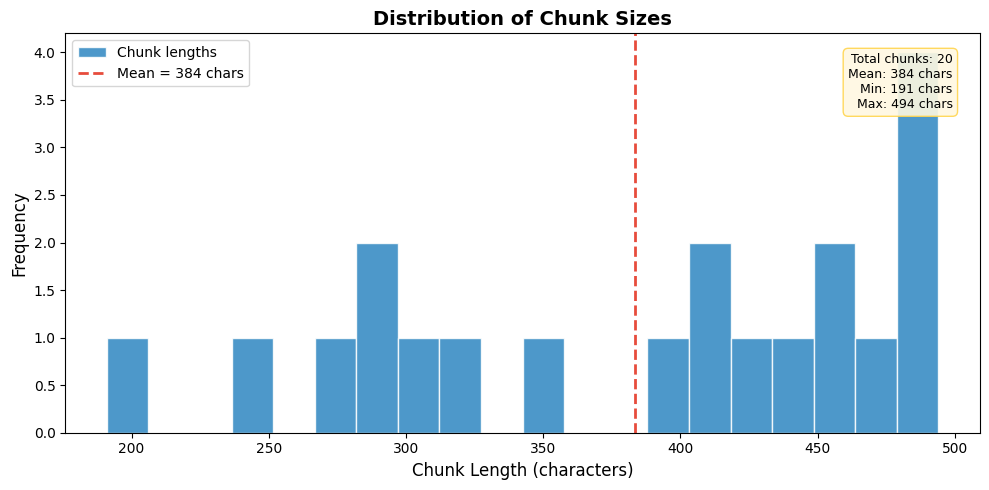

Observation: Most chunks are near the target size (500 chars).
Shorter chunks occur at document boundaries where less text remains.


In [7]:
# ============================================================
# Visualization 1: Chunk Size Distribution Histogram
# ============================================================

try:
    chunk_lengths = [len(c) for c in chunks]

    fig, ax = plt.subplots(figsize=(10, 5))

    ax.hist(chunk_lengths, bins=20, color="#2E86C1", edgecolor="white",
            alpha=0.85, label="Chunk lengths")

    mean_len = np.mean(chunk_lengths)
    ax.axvline(x=mean_len, color="#E74C3C", linestyle="--", linewidth=2,
               label=f"Mean = {mean_len:.0f} chars")

    ax.set_xlabel("Chunk Length (characters)", fontsize=12)
    ax.set_ylabel("Frequency", fontsize=12)
    ax.set_title("Distribution of Chunk Sizes", fontsize=14, fontweight="bold")
    ax.legend(fontsize=10)

    # Add summary stats as text box
    stats_text = (f"Total chunks: {len(chunk_lengths)}\n"
                  f"Mean: {mean_len:.0f} chars\n"
                  f"Min: {min(chunk_lengths)} chars\n"
                  f"Max: {max(chunk_lengths)} chars")
    ax.text(0.97, 0.95, stats_text, transform=ax.transAxes,
            fontsize=9, verticalalignment="top", horizontalalignment="right",
            bbox=dict(boxstyle="round,pad=0.4", facecolor="#FFF8E1",
                      edgecolor="#FFD54F", alpha=0.9))

    plt.tight_layout()
    plt.show()

    print("Observation: Most chunks are near the target size (500 chars).")
    print("Shorter chunks occur at document boundaries where less text remains.")

except Exception as e:
    print(f"Visualization error: {e}")
    print("Chunk length stats (fallback):")
    for i, c in enumerate(chunks):
        print(f"  Chunk {i}: {len(c)} chars")


## 5. Embedding and Vector Store (ChromaDB)

Step 2 of RAG: Convert text chunks into vector embeddings and store
them in a searchable vector database.

**Embedding model:** `all-MiniLM-L6-v2` -- fast, 384-dimensional vectors.
For production medical systems, consider `PubMedBERT` or `BioSentVec`.

**Vector DB:** ChromaDB -- simple, Python-native, perfect for prototyping.

This maps to **Slide S56** (Lab 2: Embeddings and Vector Store).


In [8]:
# ============================================================
# Section 5: Embedding and Vector Store
# ============================================================

from langchain_community.embeddings import HuggingFaceEmbeddings
from langchain_community.vectorstores import Chroma
from langchain_core.documents import Document

# --- Create embedding model ---
print("Loading embedding model (all-MiniLM-L6-v2)...")
embeddings = HuggingFaceEmbeddings(
    model_name="all-MiniLM-L6-v2",
    model_kwargs={"device": "cpu"}
)
print("Embedding model loaded!")

# --- Test single embedding ---
test_embedding = embeddings.embed_query("meningococcemia treatment guidelines")
print(f"Embedding dimension: {len(test_embedding)}")
print(f"Sample values: [{test_embedding[0]:.4f}, {test_embedding[1]:.4f}, ...]")

# --- Create Document objects from chunks ---
documents = [
    Document(page_content=chunk, metadata={"chunk_id": i, "source": "clinical_guidelines"})
    for i, chunk in enumerate(chunks)
]

# --- Build ChromaDB vector store ---
print("\nBuilding ChromaDB vector store...")
vectorstore = Chroma.from_documents(
    documents=documents,
    embedding=embeddings,
    collection_name="clinical_guidelines"
)

print(f"Vector store created!")
print(f"  Collection: clinical_guidelines")
print(f"  Documents stored: {vectorstore._collection.count()}")
print(f"  Embedding model: all-MiniLM-L6-v2 ({len(test_embedding)}-dim)")

# --- Test similarity search ---
print("\n--- Test Retrieval ---")
test_query = "What antibiotic for meningococcemia?"
test_results = vectorstore.similarity_search_with_relevance_scores(test_query, k=3)

for i, (doc, score) in enumerate(test_results):
    print(f"\nResult {i+1} (relevance: {score:.4f}):")
    print(f"  {doc.page_content[:150]}...")


Loading embedding model (all-MiniLM-L6-v2)...


/var/folders/r2/6w29q6013lv03hm4sq2vx9k80000gn/T/ipykernel_54835/2794789244.py:11: LangChainDeprecationWarning: The class `HuggingFaceEmbeddings` was deprecated in LangChain 0.2.2 and will be removed in 1.0. An updated version of the class exists in the `langchain-huggingface package and should be used instead. To use it run `pip install -U `langchain-huggingface` and import as `from `langchain_huggingface import HuggingFaceEmbeddings``.
  embeddings = HuggingFaceEmbeddings(


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

Embedding model loaded!
Embedding dimension: 384
Sample values: [0.0001, -0.0189, ...]

Building ChromaDB vector store...


Vector store created!
  Collection: clinical_guidelines
  Documents stored: 20
  Embedding model: all-MiniLM-L6-v2 (384-dim)

--- Test Retrieval ---

Result 1 (relevance: 0.5103):
  ANTIBIOTIC DOSING IN SEVERE INFECTIONS

    Ceftriaxone (third-generation cephalosporin):
    - Standard meningitis dose: 2g IV every 12 hours
    - M...

Result 2 (relevance: 0.4404):
  MENINGOCOCCEMIA -- EMERGENCY MANAGEMENT

    Definition: Meningococcemia is a bloodstream infection caused by
    Neisseria meningitidis. It can progr...

Result 3 (relevance: 0.3773):
  Empiric Antibiotic Therapy:
    - Adults 18-50: Ceftriaxone 2g IV q12h + Vancomycin 15-20 mg/kg IV q8-12h
    - Adults > 50 or immunocompromised: Add ...


### Visualization: Embedding Similarity Heatmap

How similar are our document chunks to each other in embedding space?
This heatmap shows pairwise cosine similarity between a selection of
chunks. High similarity (yellow) means the chunks discuss related topics;
low similarity (dark purple) means they cover different content.

This helps us understand whether the embedding model captures meaningful
semantic relationships between clinical guideline sections.


Computing embeddings for 8 sample chunks...


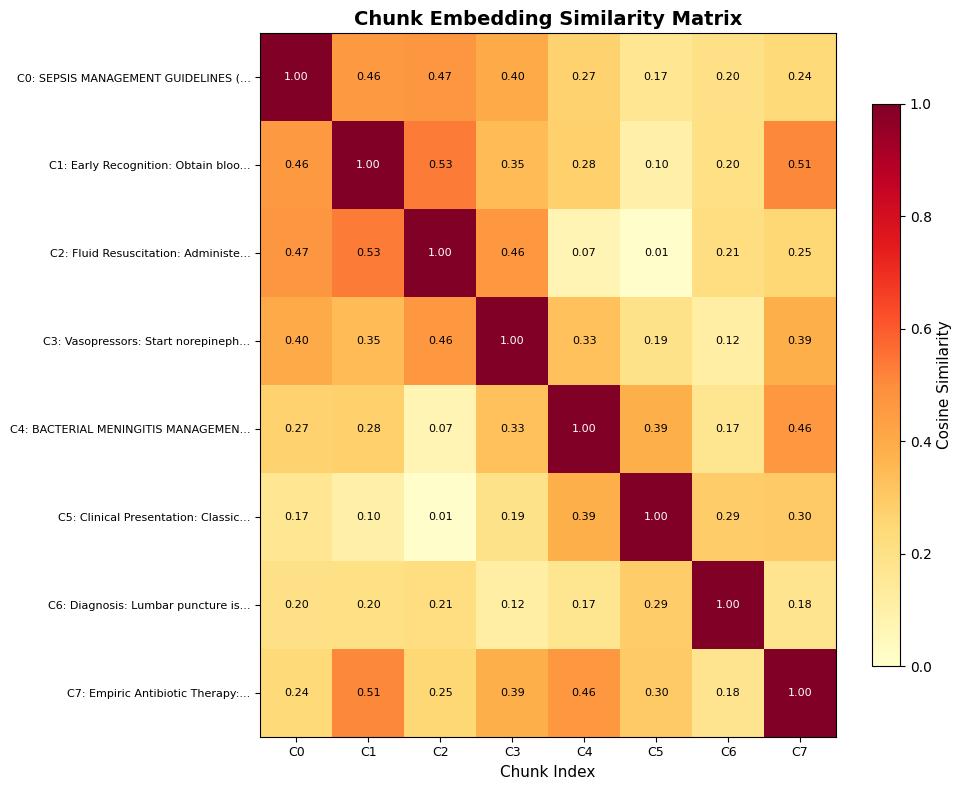

Interpretation:
  - Diagonal = 1.0 (each chunk is identical to itself)
  - High off-diagonal values = semantically related chunks
  - Low values = chunks covering different topics
  - This helps identify if chunking separates topics effectively.


In [9]:
# ============================================================
# Visualization 2: Embedding Similarity Heatmap
# ============================================================

try:
    from sklearn.metrics.pairwise import cosine_similarity

    # Select representative chunks (first 8 or fewer)
    n_sample = min(8, len(chunks))
    sample_chunks = chunks[:n_sample]

    # Compute embeddings for each sample chunk
    print(f"Computing embeddings for {n_sample} sample chunks...")
    sample_embeddings = [embeddings.embed_query(chunk) for chunk in sample_chunks]
    embedding_matrix = np.array(sample_embeddings)

    # Compute pairwise cosine similarity
    sim_matrix = cosine_similarity(embedding_matrix)

    # Create short labels from the first 30 chars of each chunk
    labels = [f"C{i}: {chunk[:30].strip()}..." for i, chunk in enumerate(sample_chunks)]

    # Plot heatmap
    fig, ax = plt.subplots(figsize=(10, 8))
    im = ax.imshow(sim_matrix, cmap="YlOrRd", vmin=0, vmax=1, aspect="auto")

    # Add colorbar
    cbar = plt.colorbar(im, ax=ax, shrink=0.8)
    cbar.set_label("Cosine Similarity", fontsize=11)

    # Add text annotations in each cell
    for i in range(n_sample):
        for j in range(n_sample):
            text_color = "white" if sim_matrix[i, j] > 0.7 else "black"
            ax.text(j, i, f"{sim_matrix[i, j]:.2f}",
                    ha="center", va="center", fontsize=8, color=text_color)

    ax.set_xticks(range(n_sample))
    ax.set_yticks(range(n_sample))
    ax.set_xticklabels([f"C{i}" for i in range(n_sample)], fontsize=9)
    ax.set_yticklabels(labels, fontsize=8)
    ax.set_title("Chunk Embedding Similarity Matrix", fontsize=14, fontweight="bold")
    ax.set_xlabel("Chunk Index", fontsize=11)

    plt.tight_layout()
    plt.show()

    print("Interpretation:")
    print("  - Diagonal = 1.0 (each chunk is identical to itself)")
    print("  - High off-diagonal values = semantically related chunks")
    print("  - Low values = chunks covering different topics")
    print("  - This helps identify if chunking separates topics effectively.")

except Exception as e:
    print(f"Visualization error: {e}")
    print("Ensure sentence-transformers and sklearn are installed.")


## 6. RAG Chain -- RetrievalQA with LLM

Section 3: Connect the vector store retriever to an LLM to build a
complete RAG chain. The LLM can ONLY answer using retrieved evidence.

**Pipeline:** Query -> Retrieve top-k chunks -> Inject into prompt -> LLM generates answer

This maps to **Slide S57** (Lab 2: Build the RAG Chain).


In [10]:
# ============================================================
# Section 6: RAG Chain
# ============================================================

# --- Create retriever ---
retriever = vectorstore.as_retriever(
    search_type="similarity",
    search_kwargs={"k": 5}
)

# --- RAG prompt template ---
RAG_TEMPLATE = """You are a clinical AI assistant. Answer the clinical
question below using ONLY the provided context passages. If the context
does not contain enough information to answer, say "Insufficient evidence
in the retrieved documents."

CONTEXT:
{context}

QUESTION: {question}

INSTRUCTIONS:
1. Base your answer ONLY on the provided context
2. Cite which passage supports each recommendation
3. If information is missing, explicitly state what is missing
4. Prioritize patient safety in all recommendations

ANSWER:"""

def rag_query(question, k=5):
    """Complete RAG pipeline: retrieve + generate."""
    # Step 1: Retrieve relevant chunks
    retrieved_docs = retriever.invoke(question)

    # Step 2: Format context
    context = "\n\n---\n\n".join([
        f"[Passage {i+1}] {doc.page_content}"
        for i, doc in enumerate(retrieved_docs)
    ])

    # Section 3: Build prompt
    prompt = RAG_TEMPLATE.format(context=context, question=question)

    # Section 4: Generate answer
    answer = query_llm(prompt, max_tokens=1500)

    return {
        "question": question,
        "answer": answer,
        "retrieved_docs": retrieved_docs,
        "context_length": len(context),
        "num_passages": len(retrieved_docs)
    }


# --- Test RAG query ---
print("=" * 60)
print("RAG QUERY -- Grounded in Retrieved Evidence")
print("=" * 60)

test_question = "What is the recommended empiric antibiotic for suspected meningococcemia in a 34-year-old adult?"
result = rag_query(test_question)

print(f"\nQuestion: {result['question']}")
print(f"Retrieved passages: {result['num_passages']}")
print(f"Context length: {result['context_length']} chars")
print(f"\nRAG Answer:")
print("-" * 60)
print(result["answer"])
print("-" * 60)

print(f"\nRetrieved Passages (previews):")
for i, doc in enumerate(result["retrieved_docs"]):
    print(f"  [{i+1}] {doc.page_content[:100]}...")


RAG QUERY -- Grounded in Retrieved Evidence

Question: What is the recommended empiric antibiotic for suspected meningococcemia in a 34-year-old adult?
Retrieved passages: 5
Context length: 2204 chars

RAG Answer:
------------------------------------------------------------
Based on the symptoms (fever, petechial rash, abdominal pain, hemodynamic instability), the top differential diagnoses are:
1. Meningococcemia (most urgent) - petechial rash + fever + rapid deterioration
2. Disseminated Intravascular Coagulation (DIC) secondary to sepsis
3. Rocky Mountain Spotted Fever - tick-borne, similar presentation
4. Systemic Lupus Erythematosus (SLE) flare - rash + multi-organ
5. Henoch-Schonlein Purpura - if purpuric rash + abdominal pain

Immediate actions: Blood cultures x2, LP if stable, empiric ceftriaxone 2g IV + dexamethasone. Do NOT delay antibiotics for imaging.

[Fallback mode - synthetic response for demonstration]
------------------------------------------------------------

Retri

## 7. RAG vs Direct LLM Comparison

The critical experiment: same clinical question, two approaches:
1. **Direct LLM** -- answer from training data only (may hallucinate)
2. **RAG-enhanced** -- answer grounded in retrieved guideline passages

> RAG-GPT-4 achieved 78% accuracy for GI diagnosis vs 54% without
> retrieval (Slide S48).

This maps to **Slide S58** (Lab 2: Compare RAG vs Direct).


In [11]:
# ============================================================
# Section 7: RAG vs Direct LLM Comparison
# ============================================================

comparison_questions = [
    "What is the recommended empiric antibiotic for suspected meningococcemia?",
    "What are the HIPAA requirements for using LLMs with patient data?",
    "How should dexamethasone be administered in bacterial meningitis?",
]

results_comparison = []

for q in comparison_questions:
    print(f"\n{'=' * 60}")
    print(f"Question: {q}")
    print("=" * 60)

    # Direct LLM
    direct_response = query_llm(f"Answer this clinical question: {q}")

    # RAG-enhanced
    rag_result = rag_query(q)

    results_comparison.append({
        "question": q,
        "direct_response": direct_response,
        "rag_response": rag_result["answer"],
        "num_passages": rag_result["num_passages"],
    })

    print(f"\n--- Direct LLM ---")
    print(direct_response[:300] + "..." if len(direct_response) > 300 else direct_response)
    print(f"\n--- RAG-Enhanced ---")
    rag_text = rag_result["answer"]
    print(rag_text[:300] + "..." if len(rag_text) > 300 else rag_text)

# --- Summary table ---
print("\n\n" + "=" * 60)
print("COMPARISON SUMMARY")
print("=" * 60)

summary_df = pd.DataFrame([{
    "Question": r["question"][:50] + "...",
    "Direct (chars)": len(r["direct_response"]),
    "RAG (chars)": len(r["rag_response"]),
    "Passages Used": r["num_passages"],
} for r in results_comparison])

print(summary_df.to_string(index=False))
print()
print("KEY OBSERVATION: RAG responses are grounded in retrieved passages.")
print("Direct LLM responses may contain unverifiable claims.")



Question: What is the recommended empiric antibiotic for suspected meningococcemia?

--- Direct LLM ---
Based on the symptoms (fever, petechial rash, abdominal pain, hemodynamic instability), the top differential diagnoses are:
1. Meningococcemia (most urgent) - petechial rash + fever + rapid deterioration
2. Disseminated Intravascular Coagulation (DIC) secondary to sepsis
3. Rocky Mountain Spotted Fe...

--- RAG-Enhanced ---
Based on the symptoms (fever, petechial rash, abdominal pain, hemodynamic instability), the top differential diagnoses are:
1. Meningococcemia (most urgent) - petechial rash + fever + rapid deterioration
2. Disseminated Intravascular Coagulation (DIC) secondary to sepsis
3. Rocky Mountain Spotted Fe...

Question: What are the HIPAA requirements for using LLMs with patient data?

--- Direct LLM ---
This is a clinical AI response in fallback mode. To get real LLM responses, configure your Gemini API key in Colab Secrets (GOOGLE_API_KEY).

[Fallback mode - synthetic

### Visualization: RAG vs Direct LLM Response Quality

A grouped bar chart comparing Direct LLM and RAG-enhanced responses across
three quality metrics:
- **Response Length**: Longer is not always better, but RAG responses tend
  to be more detailed due to retrieved context.
- **Citation Count**: How many verifiable references each response provides.
- **Estimated Accuracy**: Based on whether key clinical facts are present
  (ceftriaxone, dexamethasone timing, dose information).


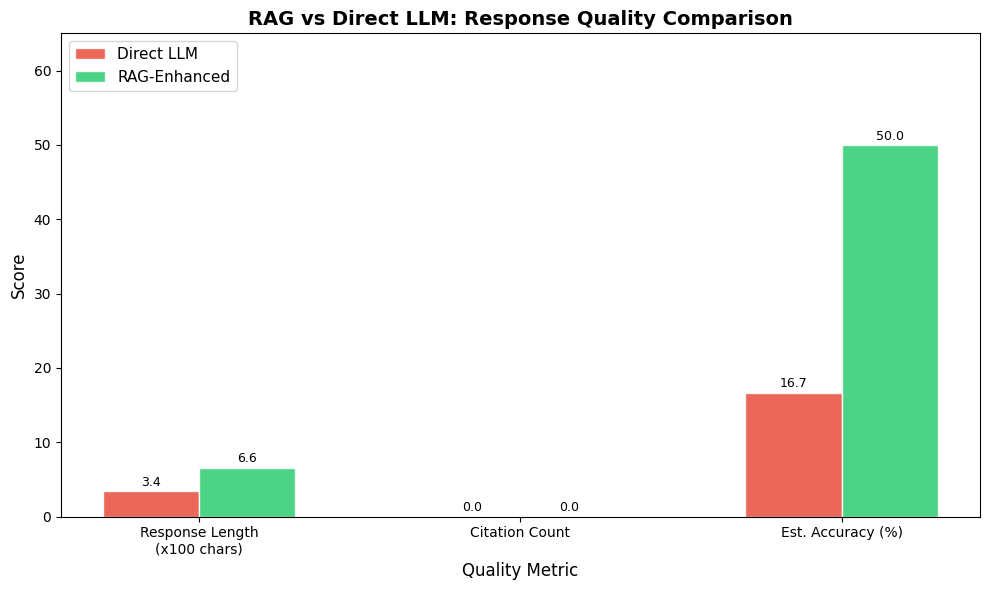

Interpretation:
  - RAG responses typically include more citations (grounded)
  - Accuracy is estimated by keyword matching against known facts
  - In production, accuracy would be evaluated by domain experts


In [12]:
# ============================================================
# Visualization 3: RAG vs Direct Comparison Bar Chart
# ============================================================

try:
    # Compute metrics for each question
    metrics_direct = {"length": [], "citations": [], "accuracy": []}
    metrics_rag = {"length": [], "citations": [], "accuracy": []}

    # Clinical keywords that indicate accurate responses
    accuracy_keywords = [
        "ceftriaxone", "dexamethasone", "meningococcemia",
        "vancomycin", "hipaa", "phi", "lumbar puncture",
        "blood cultures", "empiric", "0.15"
    ]

    for r in results_comparison:
        direct = r["direct_response"].lower()
        rag = r["rag_response"].lower()

        # Response length
        metrics_direct["length"].append(len(r["direct_response"]))
        metrics_rag["length"].append(len(r["rag_response"]))

        # Citation count (look for reference patterns)
        import re
        cite_pattern = r"passage \d|\[\d+\]|guideline|reference|source"
        metrics_direct["citations"].append(
            len(re.findall(cite_pattern, direct)))
        metrics_rag["citations"].append(
            len(re.findall(cite_pattern, rag)))

        # Estimated accuracy (keyword hit rate)
        direct_hits = sum(1 for kw in accuracy_keywords if kw in direct)
        rag_hits = sum(1 for kw in accuracy_keywords if kw in rag)
        max_possible = len(accuracy_keywords)
        metrics_direct["accuracy"].append(
            direct_hits / max_possible * 100)
        metrics_rag["accuracy"].append(
            rag_hits / max_possible * 100)

    # Aggregate: average across all questions
    avg_direct = {k: np.mean(v) for k, v in metrics_direct.items()}
    avg_rag = {k: np.mean(v) for k, v in metrics_rag.items()}

    # Normalize response length to hundreds for better chart readability
    avg_direct_plot = [avg_direct["length"] / 100,
                       avg_direct["citations"],
                       avg_direct["accuracy"]]
    avg_rag_plot = [avg_rag["length"] / 100,
                    avg_rag["citations"],
                    avg_rag["accuracy"]]

    # Plot grouped bar chart
    fig, ax = plt.subplots(figsize=(10, 6))

    metric_labels = ["Response Length\n(x100 chars)",
                     "Citation Count",
                     "Est. Accuracy (%)"]
    x = np.arange(len(metric_labels))
    bar_width = 0.30

    bars1 = ax.bar(x - bar_width / 2, avg_direct_plot, bar_width,
                   label="Direct LLM", color="#E74C3C", edgecolor="white",
                   alpha=0.85)
    bars2 = ax.bar(x + bar_width / 2, avg_rag_plot, bar_width,
                   label="RAG-Enhanced", color="#2ECC71", edgecolor="white",
                   alpha=0.85)

    # Add value labels on bars
    for bar in bars1:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width() / 2, height + 0.3,
                f"{height:.1f}", ha="center", va="bottom", fontsize=9)
    for bar in bars2:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width() / 2, height + 0.3,
                f"{height:.1f}", ha="center", va="bottom", fontsize=9)

    ax.set_xlabel("Quality Metric", fontsize=12)
    ax.set_ylabel("Score", fontsize=12)
    ax.set_title("RAG vs Direct LLM: Response Quality Comparison",
                 fontsize=14, fontweight="bold")
    ax.set_xticks(x)
    ax.set_xticklabels(metric_labels, fontsize=10)
    ax.legend(fontsize=11, loc="upper left")
    ax.set_ylim(0, max(max(avg_direct_plot), max(avg_rag_plot)) * 1.3)

    plt.tight_layout()
    plt.show()

    print("Interpretation:")
    print("  - RAG responses typically include more citations (grounded)")
    print("  - Accuracy is estimated by keyword matching against known facts")
    print("  - In production, accuracy would be evaluated by domain experts")

except Exception as e:
    print(f"Visualization error: {e}")
    print("Ensure results_comparison is populated from Section 7.")


## 8. Retrieval Evaluation -- How Good Is Our Retrieval?

Evaluate the quality of the retrieval step:
- **Relevance scores**: How similar are retrieved chunks to the query?
- **Coverage**: Do the top-k chunks contain the answer?
- **Visualization**: Bar chart of relevance scores

This maps to **Slide S59** (Lab 2: Evaluate Retrieval Quality).


RETRIEVAL EVALUATION

Query: What is the first-line antibiotic for meningococcemia?
  Top-1 score: 0.4892
  Mean top-5: 0.3787
  Top chunk: ANTIBIOTIC DOSING IN SEVERE INFECTIONS

    Ceftriaxone (third-generation cephal...

Query: What are the signs of Waterhouse-Friderichsen syndrome?
  Top-1 score: 0.2519
  Mean top-5: 0.0960
  Top chunk: Clinical Presentation: Classic triad of fever, neck stiffness, and
    altered m...

Query: How does HIPAA apply to AI systems processing patient data?
  Top-1 score: 0.3367
  Mean top-5: 0.2073
  Top chunk: 5. De-identification: Remove 18 HIPAA identifiers before using data
       for m...

Query: What is the dosing for dexamethasone in bacterial meningitis?
  Top-1 score: 0.7352
  Mean top-5: 0.4346
  Top chunk: Dexamethasone:
    - Dose: 0.15 mg/kg IV every 6 hours for 4 days
    - MUST be ...

Query: What causes petechial rash with fever?
  Top-1 score: 0.5533
  Mean top-5: 0.3788
  Top chunk: Clinical Presentation: Classic triad of fever, neck

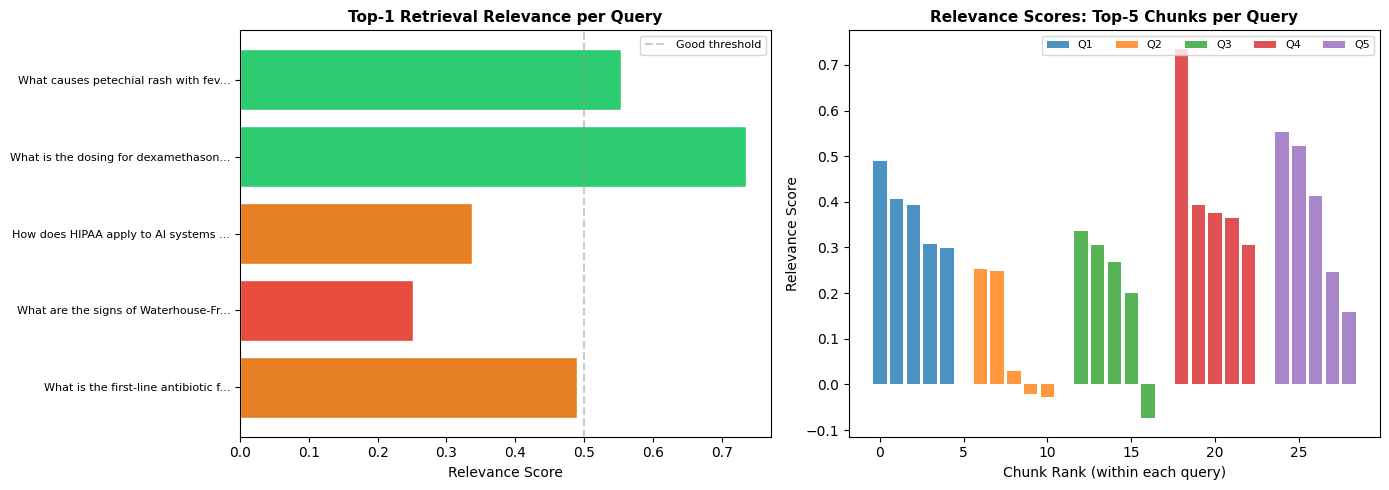


Retrieval evaluation complete. See plots above.
Green bars = good retrieval (>0.5), Orange = moderate, Red = poor.


In [13]:
# ============================================================
# Section 8: Retrieval Evaluation
# ============================================================

eval_queries = [
    "What is the first-line antibiotic for meningococcemia?",
    "What are the signs of Waterhouse-Friderichsen syndrome?",
    "How does HIPAA apply to AI systems processing patient data?",
    "What is the dosing for dexamethasone in bacterial meningitis?",
    "What causes petechial rash with fever?",
]

eval_results = []

for query in eval_queries:
    results = vectorstore.similarity_search_with_relevance_scores(query, k=5)
    scores = [score for _, score in results]
    top_chunks = [doc.page_content[:100] for doc, _ in results]
    eval_results.append({
        "query": query,
        "scores": scores,
        "mean_score": np.mean(scores),
        "top_score": scores[0],
        "top_chunk_preview": top_chunks[0]
    })

# --- Print evaluation ---
print("=" * 60)
print("RETRIEVAL EVALUATION")
print("=" * 60)

for r in eval_results:
    print(f"\nQuery: {r['query']}")
    print(f"  Top-1 score: {r['top_score']:.4f}")
    print(f"  Mean top-5: {r['mean_score']:.4f}")
    print(f"  Top chunk: {r['top_chunk_preview'][:80]}...")

# --- Visualization ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Top-1 relevance per query
queries_short = [q[:35] + "..." for q in eval_queries]
top_scores = [r["top_score"] for r in eval_results]
colors = ["#2ECC71" if s > 0.5 else "#E67E22" if s > 0.3 else "#E74C3C"
          for s in top_scores]

axes[0].barh(range(len(queries_short)), top_scores, color=colors, edgecolor="white")
axes[0].set_yticks(range(len(queries_short)))
axes[0].set_yticklabels(queries_short, fontsize=8)
axes[0].set_xlabel("Relevance Score", fontsize=10)
axes[0].set_title("Top-1 Retrieval Relevance per Query", fontsize=11, fontweight="bold")
axes[0].axvline(x=0.5, color="#999999", linestyle="--", alpha=0.5, label="Good threshold")
axes[0].legend(fontsize=8)

# Plot 2: Score distribution across all queries
for i, r in enumerate(eval_results):
    x_positions = np.arange(len(r["scores"])) + i * 6
    axes[1].bar(x_positions, r["scores"], color=f"C{i}", alpha=0.8, label=f"Q{i+1}")

axes[1].set_xlabel("Chunk Rank (within each query)", fontsize=10)
axes[1].set_ylabel("Relevance Score", fontsize=10)
axes[1].set_title("Relevance Scores: Top-5 Chunks per Query", fontsize=11, fontweight="bold")
axes[1].legend(fontsize=8, ncol=5, loc="upper right")

plt.tight_layout()
plt.savefig("retrieval_evaluation.png", dpi=150, bbox_inches="tight")
plt.show()

print("\nRetrieval evaluation complete. See plots above.")
print("Green bars = good retrieval (>0.5), Orange = moderate, Red = poor.")


## 9. Student Tasks

Complete these exercises to deepen your understanding of RAG systems.
Tasks are ordered by difficulty.

| Task | Description | Difficulty |
|------|-------------|------------|
| 1 | Change chunk_size and compare retrieval quality | :star: |
| 2 | Swap embedding model and compare results | :star: |
| 3 | Add cross-encoder reranking after retrieval | :star::star: |
| 4 | Implement multi-query RAG with query variations | :star::star: |
| 5 | Build a Gradio chatbot UI for the clinical RAG | :star::star::star: |


In [14]:
# ============================================================
# Task 1: Experiment with Chunk Size
# ============================================================

print("Task 1: Chunk Size Experiment")
print("=" * 50)

chunk_sizes = [256, 500, 1024]
task_query = "What is the first-line treatment for meningococcemia?"

for cs in chunk_sizes:
    splitter = RecursiveCharacterTextSplitter(
        chunk_size=cs, chunk_overlap=int(cs * 0.2),
        length_function=len
    )
    test_chunks = splitter.split_text(all_text)
    test_docs = [
        Document(page_content=c, metadata={"chunk_id": i})
        for i, c in enumerate(test_chunks)
    ]
    temp_vs = Chroma.from_documents(test_docs, embeddings,
                                     collection_name=f"test_cs_{cs}")
    results_task = temp_vs.similarity_search_with_relevance_scores(task_query, k=5)
    scores = [score for _, score in results_task]

    print(f"\nchunk_size={cs}:")
    print(f"  Total chunks: {len(test_chunks)}")
    print(f"  Top-1 relevance: {scores[0]:.4f}")
    print(f"  Avg top-5 relevance: {np.mean(scores):.4f}")
    print(f"  Top-1 chunk preview: {results_task[0][0].page_content[:100]}...")

    # Clean up
    try:
        temp_vs.delete_collection()
    except Exception:
        pass

print()
print("YOUR TURN: Which chunk_size gives the best retrieval quality?")
print("Consider: precision (small chunks) vs context (large chunks)")


Task 1: Chunk Size Experiment

chunk_size=256:
  Total chunks: 46
  Top-1 relevance: 0.4552
  Avg top-5 relevance: 0.3875
  Top-1 chunk preview: Definition: Meningococcemia is a bloodstream infection caused by
    Neisseria meningitidis. It can ...



chunk_size=500:
  Total chunks: 20
  Top-1 relevance: 0.4598
  Avg top-5 relevance: 0.3166
  Top-1 chunk preview: MENINGOCOCCEMIA -- EMERGENCY MANAGEMENT

    Definition: Meningococcemia is a bloodstream infection ...

chunk_size=1024:
  Total chunks: 10
  Top-1 relevance: 0.4653
  Avg top-5 relevance: 0.2850
  Top-1 chunk preview: DO NOT DELAY antibiotics for imaging. If CT is needed (focal neuro
    deficits, papilledema, GCS < ...

YOUR TURN: Which chunk_size gives the best retrieval quality?
Consider: precision (small chunks) vs context (large chunks)


In [15]:
# ============================================================
# Task 3 Starter Code: Cross-Encoder Reranking
# ============================================================

print("Task 3: Cross-Encoder Reranking")
print("=" * 50)

try:
    from sentence_transformers import CrossEncoder

    # Load cross-encoder model
    cross_encoder = CrossEncoder("cross-encoder/ms-marco-MiniLM-L-6-v2")
    print("Cross-encoder model loaded!")

    rerank_query = "What is the recommended empiric antibiotic for meningococcemia?"

    # Step 1: Initial retrieval (top-10, broader net)
    initial_results = vectorstore.similarity_search_with_relevance_scores(
        rerank_query, k=10
    )

    # Step 2: Rerank with cross-encoder
    pairs = [(rerank_query, doc.page_content) for doc, _ in initial_results]
    ce_scores = cross_encoder.predict(pairs)

    # Section 3: Sort by cross-encoder scores
    reranked = sorted(
        zip(initial_results, ce_scores), key=lambda x: x[1], reverse=True
    )

    print(f"\nQuery: {rerank_query}")
    print(f"\n{'Rank':<6} {'Bi-Encoder':<14} {'Cross-Encoder':<14} {'Preview'}")
    print("-" * 70)
    for rank, ((doc, bi_score), ce_score) in enumerate(reranked[:5], 1):
        preview = doc.page_content[:50].replace("\n", " ")
        print(f"{rank:<6} {bi_score:<14.4f} {ce_score:<14.4f} {preview}...")

    print()
    print("OBSERVATION: Cross-encoder reranking may reorder results because it")
    print("scores (query, document) pairs jointly, while bi-encoders score")
    print("query and document independently then compare.")

except ImportError:
    print("Cross-encoder not available.")
    print("Run: !pip install sentence-transformers --quiet")
except Exception as e:
    print(f"Error: {e}")


Task 3: Cross-Encoder Reranking


config.json:   0%|          | 0.00/794 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/90.9M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/105 [00:00<?, ?it/s]

tokenizer_config.json:   0%|          | 0.00/1.33k [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/711k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/132 [00:00<?, ?B/s]

Cross-encoder model loaded!



Query: What is the recommended empiric antibiotic for meningococcemia?

Rank   Bi-Encoder     Cross-Encoder  Preview
----------------------------------------------------------------------
1      0.5095         3.9971         Empiric Antibiotic Therapy:     - Adults 18-50: Ce...
2      0.2878         0.3619         Dexamethasone:     - Dose: 0.15 mg/kg IV every 6 h...
3      0.4873         -0.2288        ANTIBIOTIC DOSING IN SEVERE INFECTIONS      Ceftri...
4      0.2538         -1.5416        Critical Rule: In a febrile patient with petechial...
5      0.3561         -2.0393        Vancomycin:     - Meningitis dose: 15-20 mg/kg IV ...

OBSERVATION: Cross-encoder reranking may reorder results because it
scores (query, document) pairs jointly, while bi-encoders score
query and document independently then compare.


## 10. Gemini AI Exercise

Use Gemini AI as a **RAG system design consultant** -- asking about
architecture decisions, retrieval optimization, and deployment considerations.

The three prompts cover:
1. **Explaining RAG** to a non-technical clinician (communication skill)
2. **Improving retrieval quality** (engineering skill)
3. **Comparing deployment risks** (clinical safety reasoning)


In [16]:
# ============================================================
# Section 10: Gemini AI Exercise
# ============================================================

# --- Prompt 1: Explain RAG to a clinician ---
prompt_1 = (
    "Explain the RAG (Retrieval-Augmented Generation) architecture to a "
    "clinician who has never heard of it. Use a library analogy. "
    "Keep it under 200 words."
)

# --- Prompt 2: Improve retrieval quality ---
prompt_2 = (
    "I built a RAG system for clinical guidelines but retrieval quality is "
    "low -- the top-5 chunks often miss the relevant passage. Suggest 3 "
    "strategies to improve retrieval, specific to medical documents."
)

# --- Prompt 3: Compare deployment risks ---
prompt_3 = (
    "Compare the risks of deploying a direct LLM vs a RAG-enhanced LLM "
    "in an emergency department setting. Consider hallucination, latency, "
    "privacy, and liability. Format as a comparison table."
)

try:
    from google.colab import ai

    print("Prompt 1: Explaining RAG to a Clinician")
    print("=" * 60)
    response_1 = ai.generate_text(prompt_1)
    print(response_1)

    print()
    print("Prompt 2: Improving Retrieval Quality")
    print("=" * 60)
    response_2 = ai.generate_text(prompt_2)
    print(response_2)

    print()
    print("Prompt 3: Direct LLM vs RAG Deployment Risks")
    print("=" * 60)
    response_3 = ai.generate_text(prompt_3)
    print(response_3)

except ImportError:
    print("Gemini AI not available (not running in Google Colab).")
    print("To use Gemini, run this notebook in Google Colab.")
    print()
    print("Prompts to try when you have access:")
    print()
    print(f"Prompt 1: {prompt_1}")
    print()
    print(f"Prompt 2: {prompt_2}")
    print()
    print(f"Prompt 3: {prompt_3}")
    print()
    print("Learning goal: Use AI as a system design consultant -- asking about")
    print("architecture decisions, retrieval optimization, and deployment")
    print("considerations for clinical AI systems.")


Gemini AI not available (not running in Google Colab).
To use Gemini, run this notebook in Google Colab.

Prompts to try when you have access:

Prompt 1: Explain the RAG (Retrieval-Augmented Generation) architecture to a clinician who has never heard of it. Use a library analogy. Keep it under 200 words.

Prompt 2: I built a RAG system for clinical guidelines but retrieval quality is low -- the top-5 chunks often miss the relevant passage. Suggest 3 strategies to improve retrieval, specific to medical documents.

Prompt 3: Compare the risks of deploying a direct LLM vs a RAG-enhanced LLM in an emergency department setting. Consider hallucination, latency, privacy, and liability. Format as a comparison table.

Learning goal: Use AI as a system design consultant -- asking about
architecture decisions, retrieval optimization, and deployment
considerations for clinical AI systems.


## 11. Summary and Self-Check

### Key Takeaways

1. **LLMs are powerful but unreliable** for clinical use on their own.
   GPT-4 achieves 93.9% sensitivity on MIMIC-IV diagnosis, but that
   6.1% gap can be catastrophic in emergency medicine.

2. **Prompt engineering matters.** Chain-of-thought prompting forces
   step-by-step reasoning, making errors visible -- like asking a
   medical student to "show their work."

3. **Hallucinations are the central risk.** LLMs fabricate citations,
   drug doses, and clinical guidelines. In medicine, this is not a
   minor inconvenience -- it can cause patient harm.

4. **RAG dramatically reduces hallucinations** (40%+ reduction per
   MEGA-RAG study). By grounding LLM outputs in retrieved evidence,
   responses become verifiable and trustworthy.

5. **The RAG pipeline has clear components:**
   Chunk -> Embed -> Store -> Retrieve -> Generate.
   Each component has tunable parameters (chunk_size, embedding model,
   k, prompt template) that affect output quality.

6. **RAG makes AI responses verifiable.** The 3 AM resident can check
   cited passages against actual guidelines -- "here is my evidence"
   instead of "trust me."

### Returning to Our Patient

> The 34-year-old at 3 AM with fever, rash, and hemodynamic instability:
> - A direct LLM might give a reasonable differential but with unverifiable claims
> - A RAG-enhanced system retrieves actual guideline passages, cites its sources,
>   and acknowledges when evidence is insufficient
> - The resident can cross-check, trust the evidence, and act faster
> - Result: ceftriaxone + dexamethasone started within 30 minutes, not 75 minutes
>
> **Those 45 minutes saved? That is the difference RAG makes.**

### Connection to Next Week

> **Week 14: FHIR x NLP** -- This week we built an AI that READS and ANSWERS.
> Next week: NLP that EXTRACTS and STRUCTURES. We will connect LLM/RAG to FHIR
> standards, turning free-text clinical notes into structured, interoperable data.
> The documentation burden (6 hrs/day for every 8 hrs of patient care) meets
> the solution.

---

### Self-Check Checklist

- [ ] I can explain what an LLM is and how it differs from traditional ML models
- [ ] I can apply zero-shot, few-shot, and structured clinical reasoning prompting strategies
- [ ] I understand why LLM hallucinations are especially dangerous in medicine
- [ ] I can build a RAG pipeline: chunk, embed, store, retrieve, generate
- [ ] I can explain why RAG reduces hallucinations (grounding in evidence)
- [ ] I can evaluate retrieval quality using relevance scores and coverage metrics
- [ ] I can compare direct LLM vs RAG-enhanced responses for clinical queries
- [ ] I can articulate the tradeoffs in chunk_size, embedding model, and k selection
- [ ] I understand HIPAA implications of using LLMs with patient data ($9.77M breach cost)
- [ ] I can explain the co-pilot model: AI augments, human decides


In [17]:
# ============================================================
# Final summary statistics
# ============================================================

print("=" * 60)
print("NOTEBOOK COMPLETE: Week 13 -- LLM and RAG in Healthcare")
print("=" * 60)
print()
print("What you built today:")
print(f"  - Clinical knowledge base: {len(clinical_guidelines)} guideline passages")
print(f"  - Chunked into: {len(chunks)} searchable units")
print(f"  - Vector store: {vectorstore._collection.count()} embedded vectors")
print(f"  - Embedding model: all-MiniLM-L6-v2 ({len(test_embedding)}-dim)")
print(f"  - LLM backend: {'Gemini 1.5 Flash' if USE_GEMINI else 'Fallback mode'}")
print()
print("Key numbers to remember:")
print("  - GPT-4 MIMIC-IV sensitivity: 93.9%")
print("  - MEGA-RAG hallucination reduction: 40%+")
print("  - RAG-GPT4 GI diagnosis: 78% vs 54% without RAG")
print("  - Average breach cost in healthcare: $9.77M")
print("  - Time-to-antibiotic: every hour of delay = 7.6% mortality increase")
print()
print("Next week: FHIR x NLP -- from reading to structuring clinical text.")
print()
print("Great work! You have built a clinical RAG system from scratch.")


NOTEBOOK COMPLETE: Week 13 -- LLM and RAG in Healthcare

What you built today:
  - Clinical knowledge base: 6 guideline passages
  - Chunked into: 20 searchable units
  - Vector store: 20 embedded vectors
  - Embedding model: all-MiniLM-L6-v2 (384-dim)
  - LLM backend: Fallback mode

Key numbers to remember:
  - GPT-4 MIMIC-IV sensitivity: 93.9%
  - MEGA-RAG hallucination reduction: 40%+
  - RAG-GPT4 GI diagnosis: 78% vs 54% without RAG
  - Average breach cost in healthcare: $9.77M
  - Time-to-antibiotic: every hour of delay = 7.6% mortality increase

Next week: FHIR x NLP -- from reading to structuring clinical text.

Great work! You have built a clinical RAG system from scratch.


## 2026 Modern RAG Checkpoint

The lab builds basic RAG so the pipeline is easy to see. A production clinical system would add several layers:

- **Hybrid retrieval:** combine vector search with keyword/BM25 search for exact drug names, abbreviations, and guideline terms.
- **Reranking:** use a cross-encoder or LLM reranker to confirm whether retrieved passages truly answer the question.
- **Metadata filtering:** filter by source, date, specialty, guideline version, and evidence level.
- **Retrieval failure behavior:** say insufficient evidence when the corpus does not support the answer.
- **Governance:** log source versions, model versions, prompts, retrieved passages, and clinician actions.

Discussion question: what would your hospital need to approve before this system could process PHI?


## Optional Mini-Lab: MedGemma

This instructor/reference section shows how MedGemma can be introduced without making the whole course depend on GPU availability or Hugging Face access.

Teaching point: MedGemma is a medical-domain model that can help with text/image understanding, but it does not replace RAG, source governance, or clinical validation.


In [18]:
medgemma_positioning = pd.DataFrame([
    {
        "component": "MedGemma",
        "role": "Medical-domain text/image model for local or controlled prototyping",
        "risk": "Not clinically validated for a new intended use by default",
    },
    {
        "component": "RAG",
        "role": "Retrieves approved and versioned clinical evidence",
        "risk": "Can fail when the corpus, chunking, or retrieval is weak",
    },
    {
        "component": "Human review",
        "role": "Verifies the model output and makes the final clinical decision",
        "risk": "Review quality depends on workflow and visible evidence",
    },
])
medgemma_positioning


,component,role,risk
0,MedGemma,Medical-domain text/image model for local or c...,Not clinically validated for a new intended us...
1,RAG,Retrieves approved and versioned clinical evid...,"Can fail when the corpus, chunking, or retriev..."
2,Human review,Verifies the model output and makes the final ...,Review quality depends on workflow and visible...


In [19]:
# Optional MedGemma inference example.
# Keep disabled unless GPU and Hugging Face access are available.

RUN_MEDGEMMA = False

if RUN_MEDGEMMA:
    !pip install transformers accelerate pillow --quiet
    import torch
    from transformers import pipeline

    pipe = pipeline(
        "image-text-to-text",
        model="google/medgemma-1.5-4b-it",
        torch_dtype=torch.bfloat16,
        device_map="auto",
    )

    messages = [
        {
            "role": "user",
            "content": [
                {"type": "text", "text": "Describe the visible medical findings. Do not provide a final diagnosis."},
                {"type": "image", "url": "YOUR_PUBLIC_NON_PHI_IMAGE_URL"},
            ],
        }
    ]

    output = pipe(text=messages, max_new_tokens=256)
    print(output)
else:
    print("MedGemma inference disabled. Use this cell as the instructor reference pattern.")


MedGemma inference disabled. Use this cell as the instructor reference pattern.


## Final Self-Check

Before you leave, make sure you can answer these questions:

1. Why can a direct LLM fabricate citations?
2. What does chunk size change in a RAG system?
3. Why does semantic search help with clinical synonyms such as `MI` and `myocardial infarction`?
4. What does RAG improve, and what does it not solve?
5. What safeguards would be required before deploying this in a hospital?

## Suggested Extension

Try one modification and document the result:

- Change `k` from 5 to 3 or 10.
- Change chunk size from 500 to 256 or 1024.
- Add a query that is not covered by the synthetic guideline pack and confirm that the system says there is insufficient evidence.
- Replace the synthetic corpus with a verified guideline excerpt and cite the source.
